### Load Dependencies and Data

In [45]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import sys
import yaml
import numpy as np


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Add src folder to sys.path so Python can find your package

In [15]:
ROOT = Path.cwd().parent     # project root directory when working interactively
sys.path.append(str(ROOT / "src"))

Import the root folder of the project : house_prices_tensorflow

In [16]:
from pkg_house_prices.utils.project_root import PROJECT_ROOT

Import the data

In [17]:
from pkg_house_prices.data.data_loader import train, test

### Data Exploration - Data types and missing values

In [27]:
# Determine the data types of each column in the training data
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [29]:
# Return columns with object data type
object_cols = train.select_dtypes(include=['object']).columns
print("\nColumns with object data type:")
print(object_cols)
# Display first few entries of these object columns
print("\nFirst few entries of object columns:")
print(train[object_cols].head())



Columns with object data type:
Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

First few entries of object columns:
  MSZoning Street Alley LotShape LandContour Utilities LotConfig LandSlope  \
0       RL   Pave   NaN      Reg         Lvl    AllPub    Inside       Gtl   
1       RL   Pave   NaN      Reg         Lvl    AllPub       FR2       Gtl   
2       RL   Pave   NaN      IR

In [30]:
# Convert object data types into string data types for easier handling
for col in object_cols:
    train[col] = train[col].astype('string')
    test[col] = test[col].astype('string')

In [ ]:
# Count the number of missing values in each column and print the result
missing_counts = train.isnull().sum()
print("\nMissing values in each column of the training data:")
print(missing_counts[missing_counts > 0])
print("\nTotal number of columns with missing values is", len(missing_counts[missing_counts > 0]), " out of ", len(train.columns),".")


Missing values in each column of the training data:
LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

 Total number of columns with missing values is 19  out of  81 .


In [38]:
# Drop the columns with missing values for now
train = train.drop(columns=missing_counts[missing_counts > 0].index)
test = test.drop(columns=missing_counts[missing_counts > 0].index)
print("\nAfter dropping, the training data now has columns:")
print(train.info())



After dropping, the training data now has columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 62 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Id             1460 non-null   int64 
 1   MSSubClass     1460 non-null   int64 
 2   MSZoning       1460 non-null   string
 3   LotArea        1460 non-null   int64 
 4   Street         1460 non-null   string
 5   LotShape       1460 non-null   string
 6   LandContour    1460 non-null   string
 7   Utilities      1460 non-null   string
 8   LotConfig      1460 non-null   string
 9   LandSlope      1460 non-null   string
 10  Neighborhood   1460 non-null   string
 11  Condition1     1460 non-null   string
 12  Condition2     1460 non-null   string
 13  BldgType       1460 non-null   string
 14  HouseStyle     1460 non-null   string
 15  OverallQual    1460 non-null   int64 
 16  OverallCond    1460 non-null   int64 
 17  YearBuilt      1460

Summary: 
1. Columns with object datatypes were transformed to string. 
2. All columns with missing values are dropped since they only cover less than 25% of the actual number of variables. It is assumed that the remaining variables are sufficent to predict the house prices. 

### Plot the Data

(array([ 11.,  38.,  99., 232., 273., 218., 176., 104.,  93.,  58.,  42.,
         35.,  24.,  10.,  17.,   8.,   7.,   4.,   2.,   1.,   1.,   2.,
          1.,   0.,   2.,   0.,   0.,   0.,   0.,   2.]),
 array([ 34900.        ,  58903.33333333,  82906.66666667, 106910.        ,
        130913.33333333, 154916.66666667, 178920.        , 202923.33333333,
        226926.66666667, 250930.        , 274933.33333333, 298936.66666667,
        322940.        , 346943.33333333, 370946.66666667, 394950.        ,
        418953.33333333, 442956.66666667, 466960.        , 490963.33333333,
        514966.66666667, 538970.        , 562973.33333333, 586976.66666667,
        610980.        , 634983.33333333, 658986.66666667, 682990.        ,
        706993.33333333, 730996.66666667, 755000.        ]),
 <BarContainer object of 30 artists>)

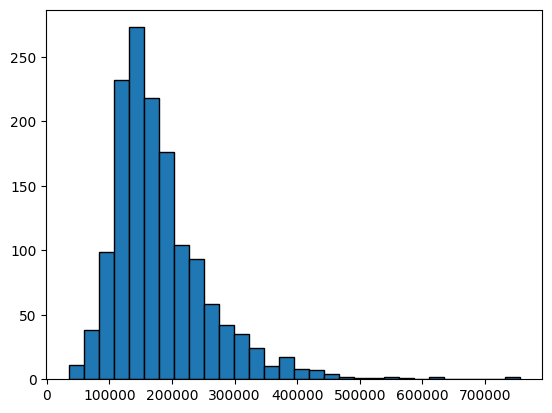

In [ ]:
# Plot the distribution of the target variable 'SalePrice'
plt.hist(train['SalePrice'], bins=30, edgecolor='black')

(array([  3.,   2.,   0.,   2.,   3.,   7.,   5.,  10.,  39.,  35.,  49.,
        100., 138., 186., 146., 156., 142., 102., 100.,  68.,  52.,  44.,
         22.,  24.,  12.,   4.,   3.,   3.,   1.,   2.]),
 array([10.46027076, 10.56274421, 10.66521767, 10.76769112, 10.87016457,
        10.97263803, 11.07511148, 11.17758493, 11.28005839, 11.38253184,
        11.48500529, 11.58747874, 11.6899522 , 11.79242565, 11.8948991 ,
        11.99737256, 12.09984601, 12.20231946, 12.30479292, 12.40726637,
        12.50973982, 12.61221328, 12.71468673, 12.81716018, 12.91963363,
        13.02210709, 13.12458054, 13.22705399, 13.32952745, 13.4320009 ,
        13.53447435]),
 <BarContainer object of 30 artists>)

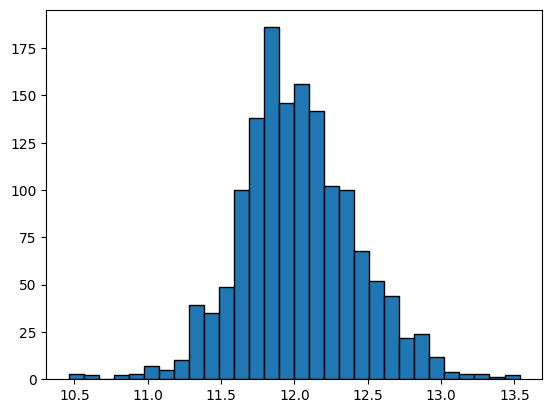

In [46]:
# From the plot above, the house price data appears to be right-skewed. A log transformation can help normalize the distribution.
plt.hist(np.log1p(train['SalePrice']), bins=30, edgecolor='black')


C:\Users\josep\AppData\Local\Temp\ipykernel_9228\594229005.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 6))


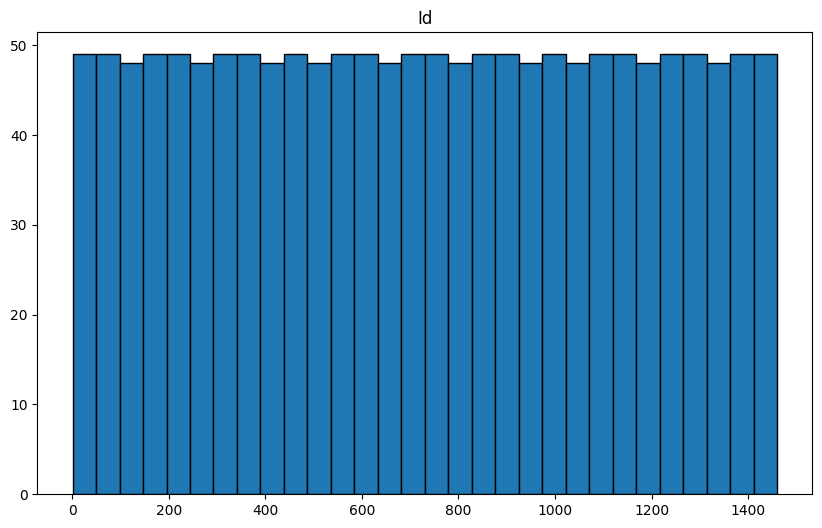

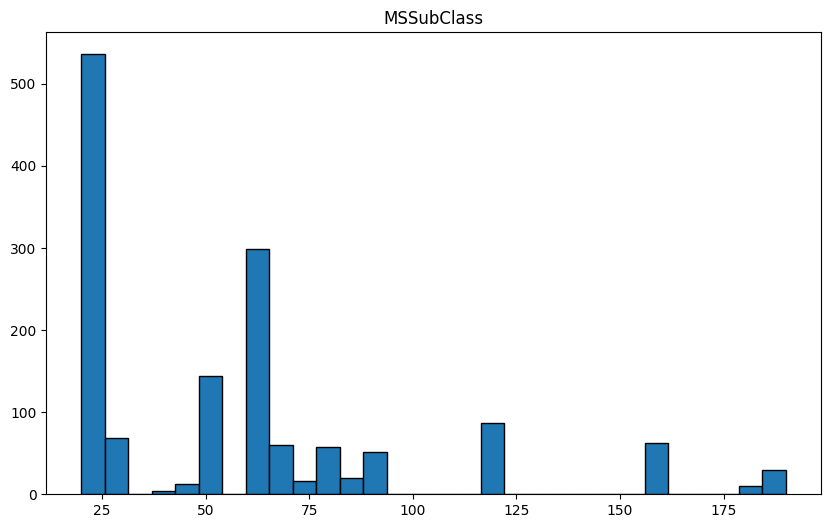

<Figure size 1000x600 with 0 Axes>

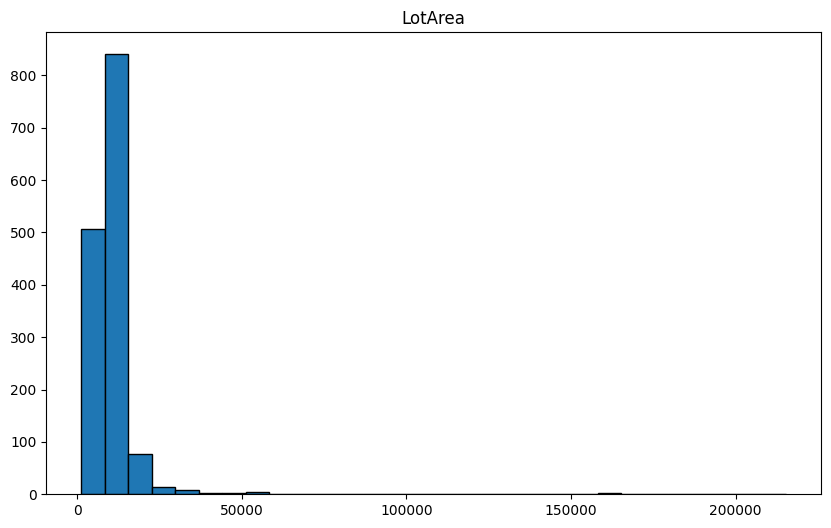

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

...

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

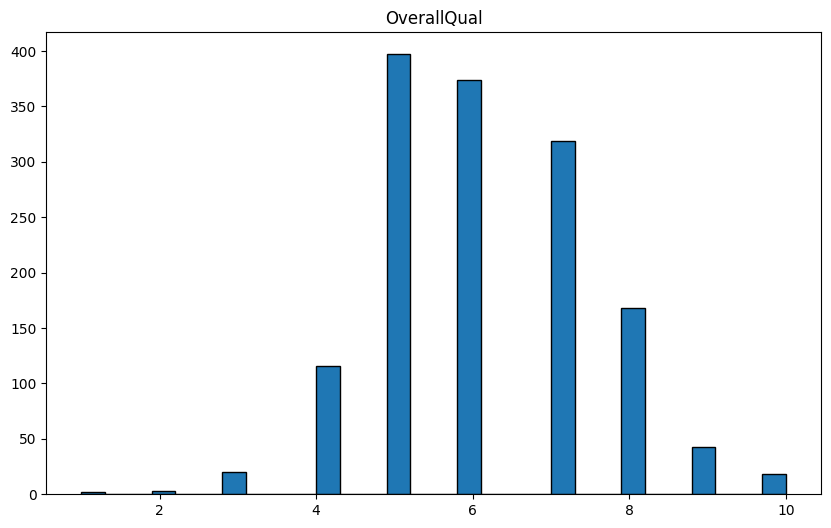

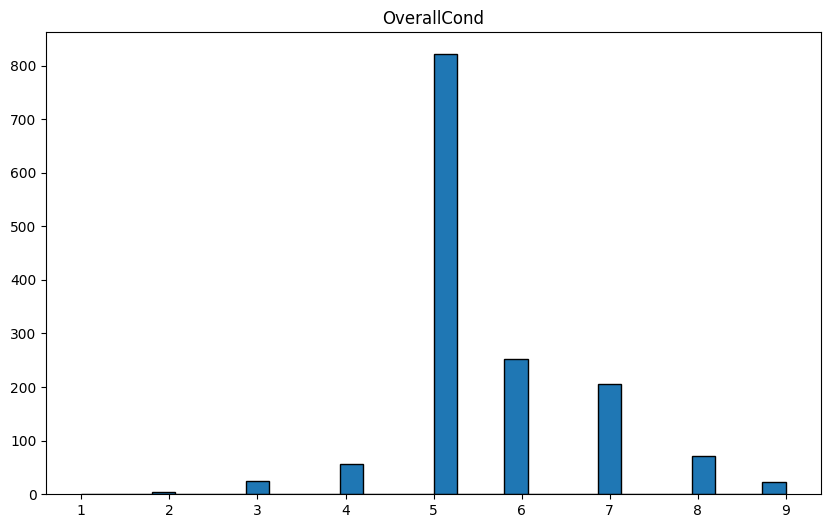

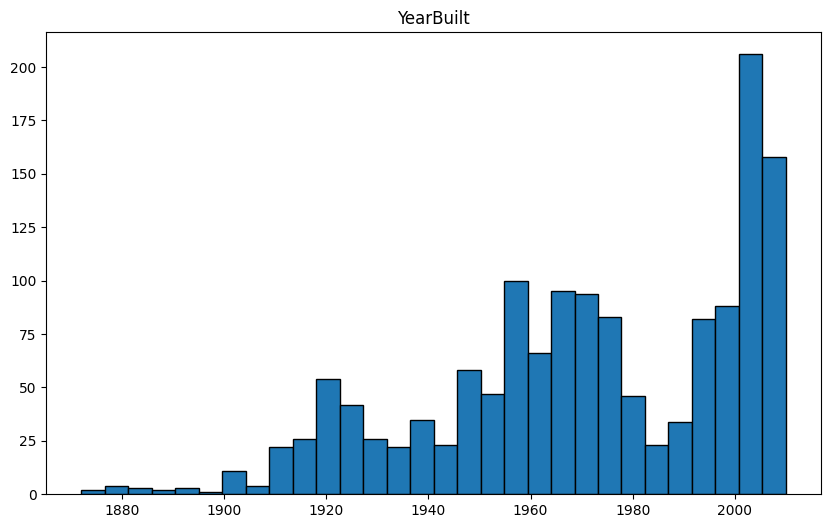

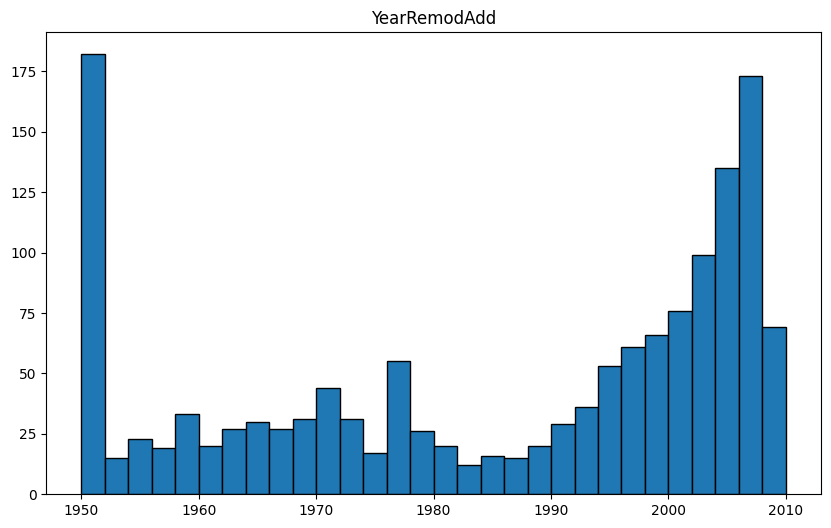

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

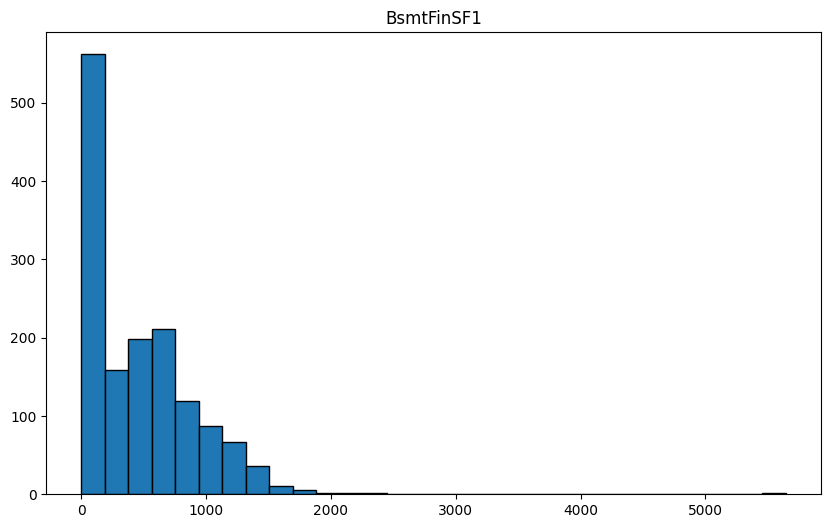

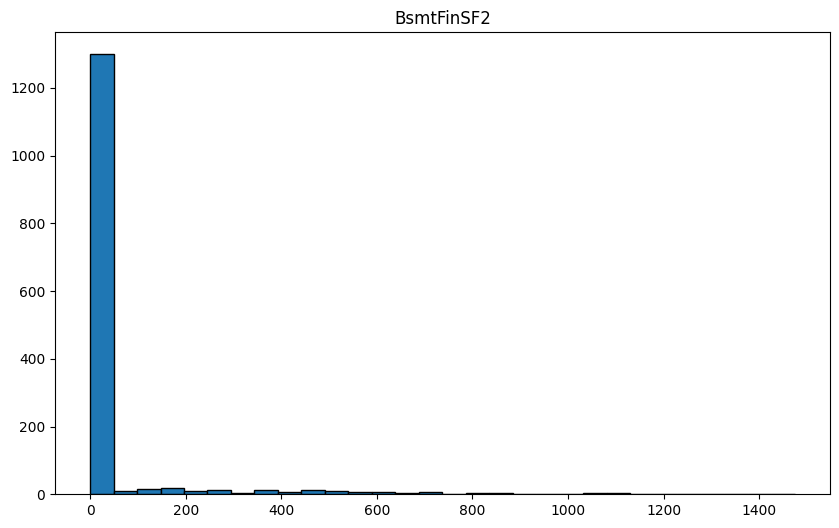

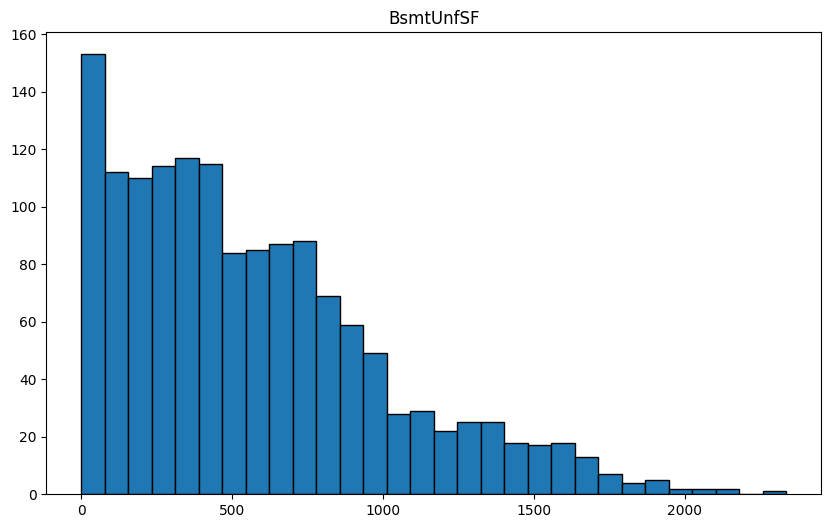

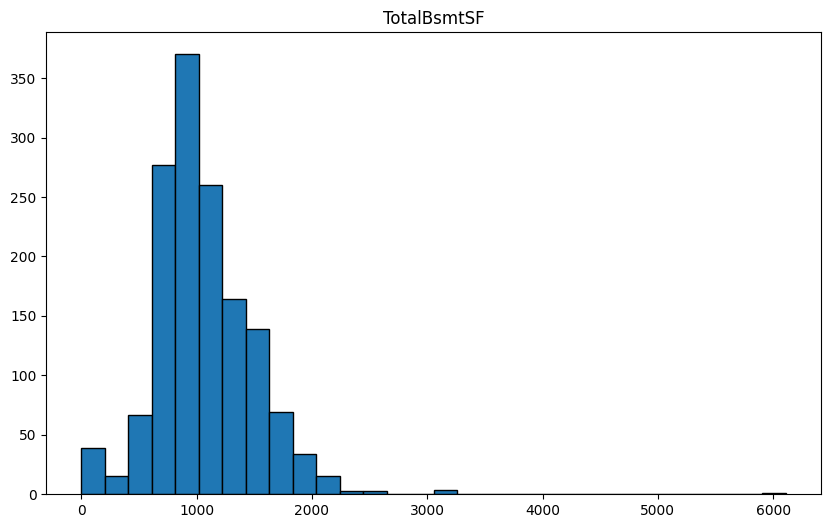

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

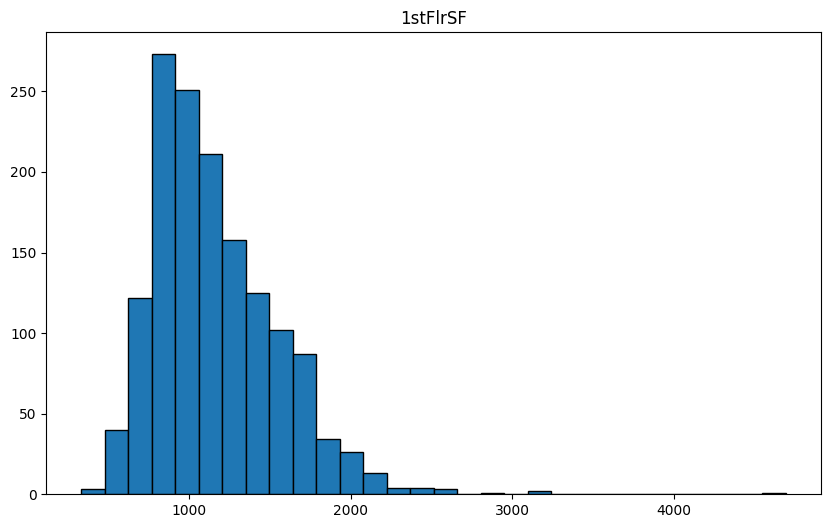

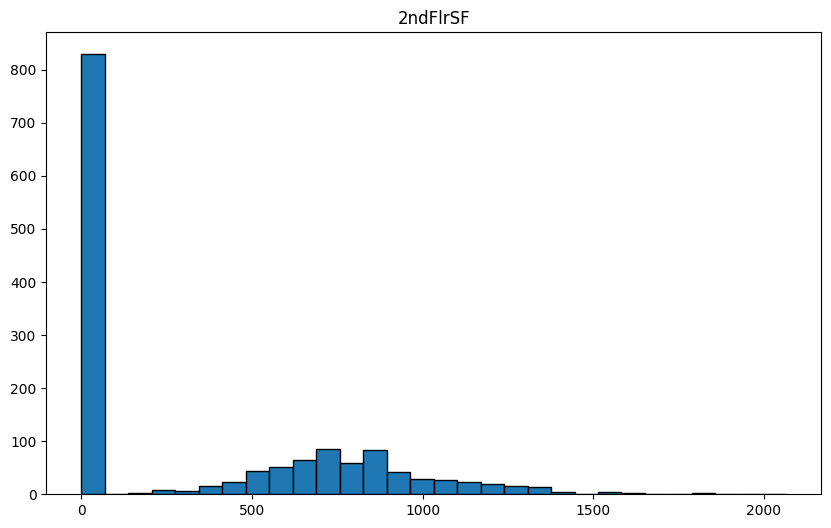

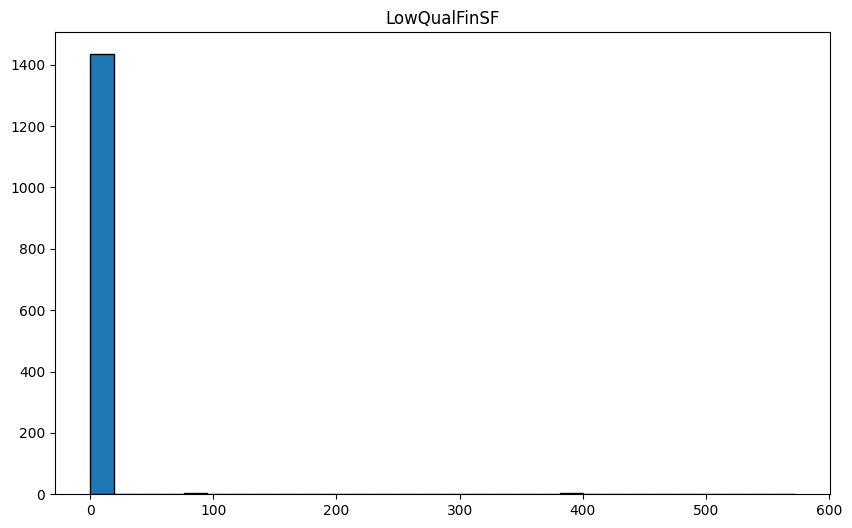

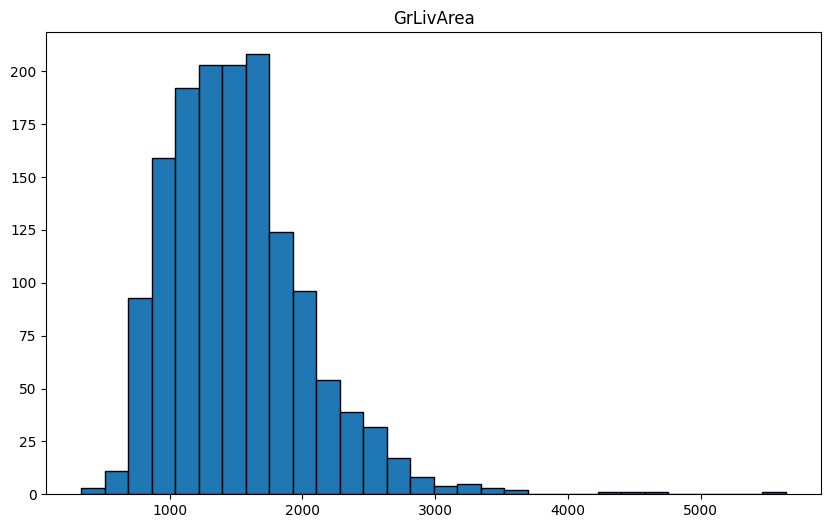

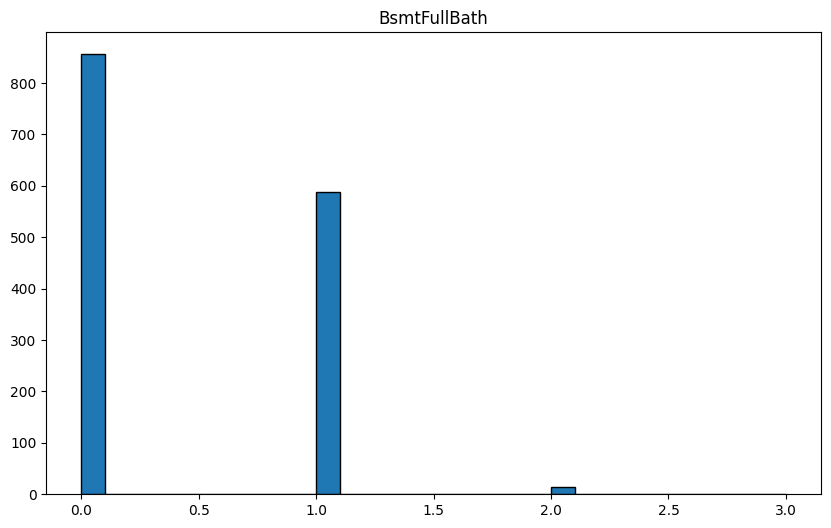

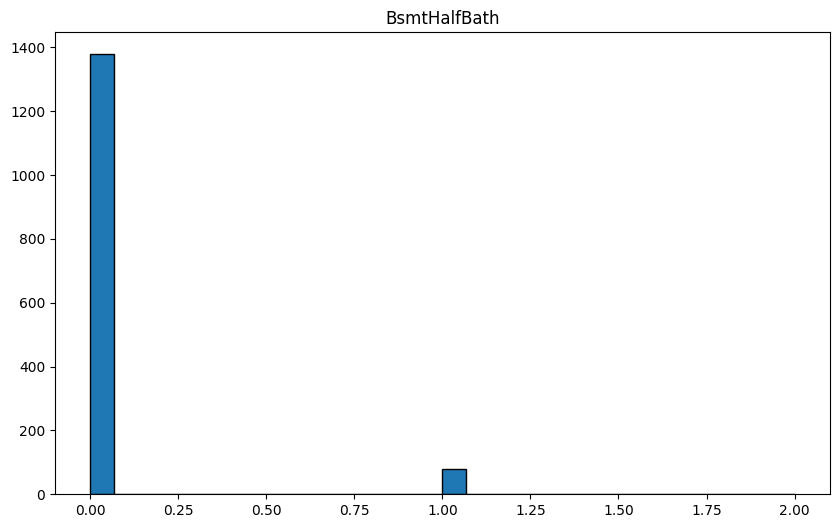

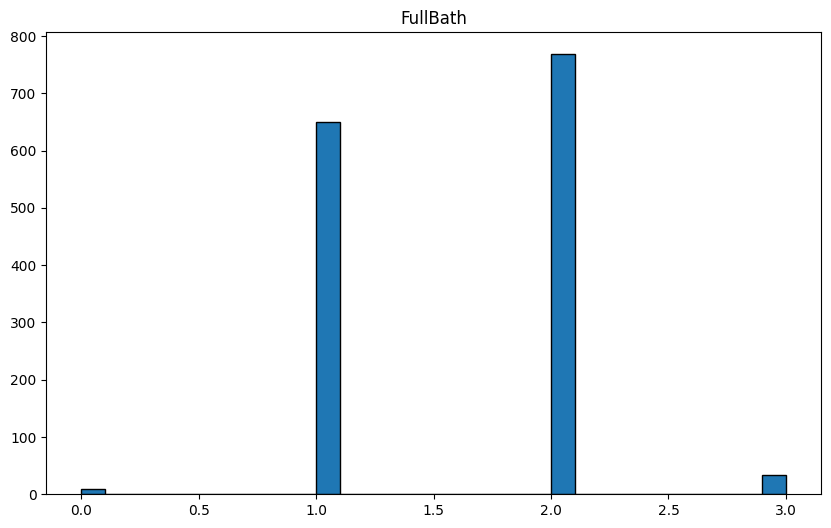

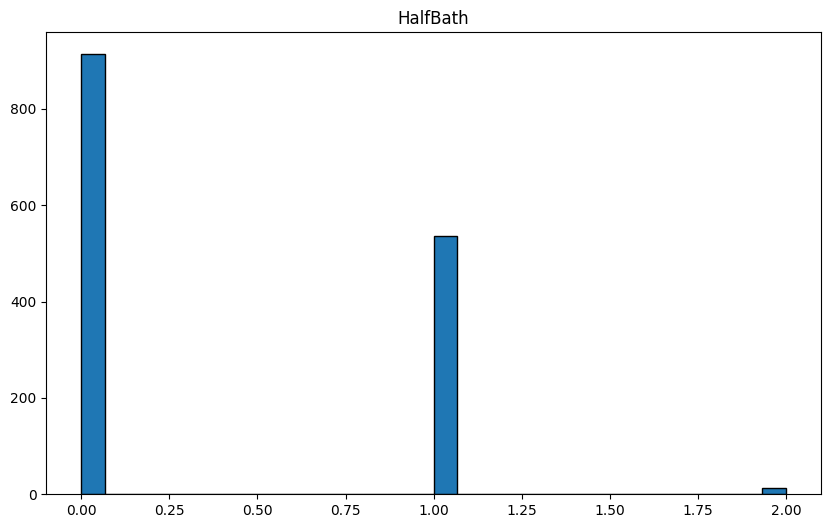

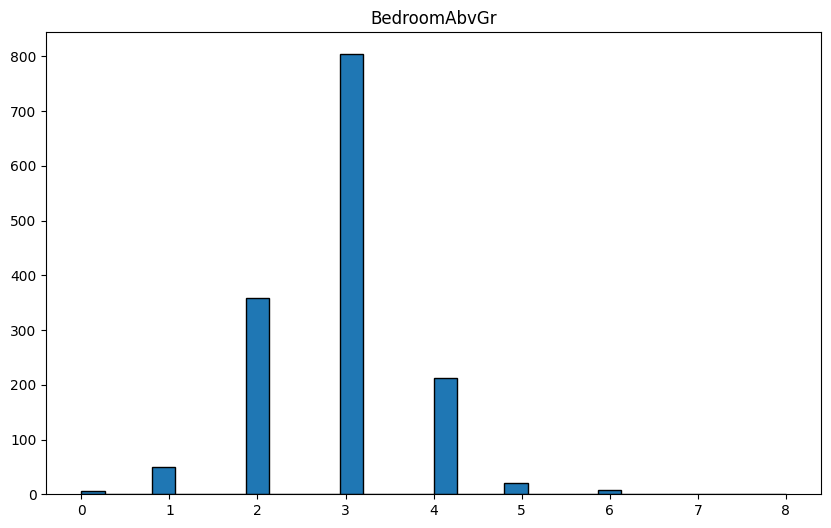

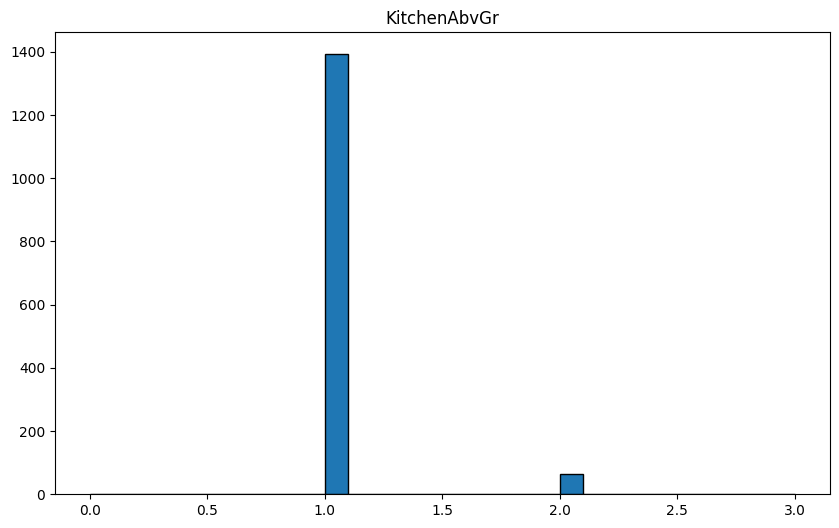

<Figure size 1000x600 with 0 Axes>

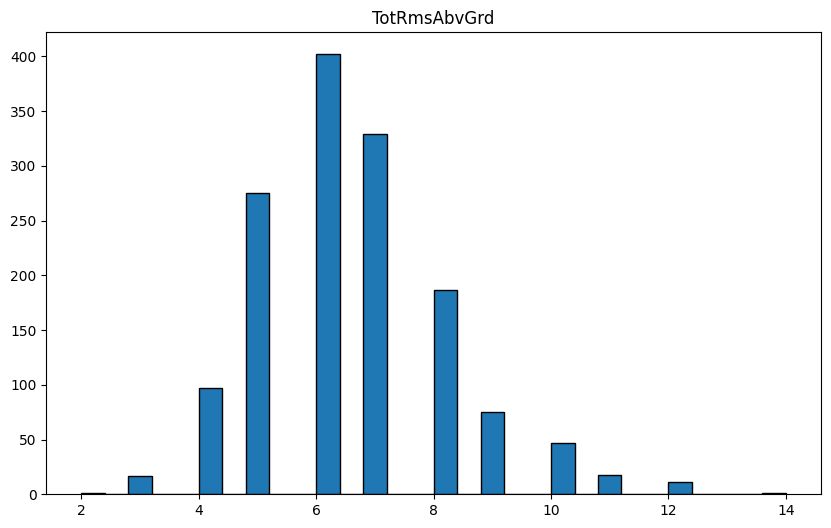

<Figure size 1000x600 with 0 Axes>

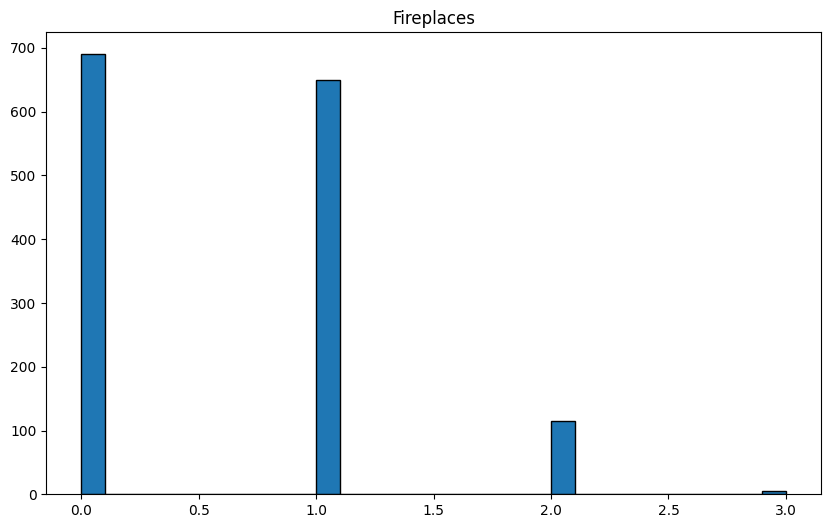

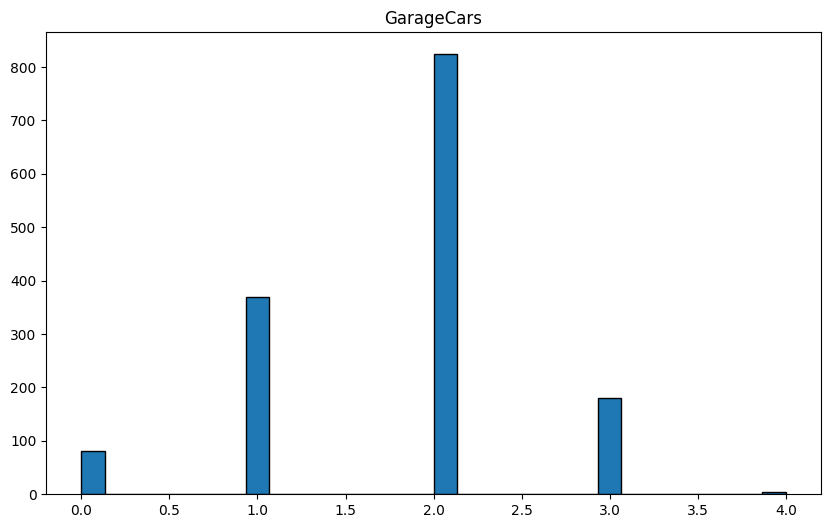

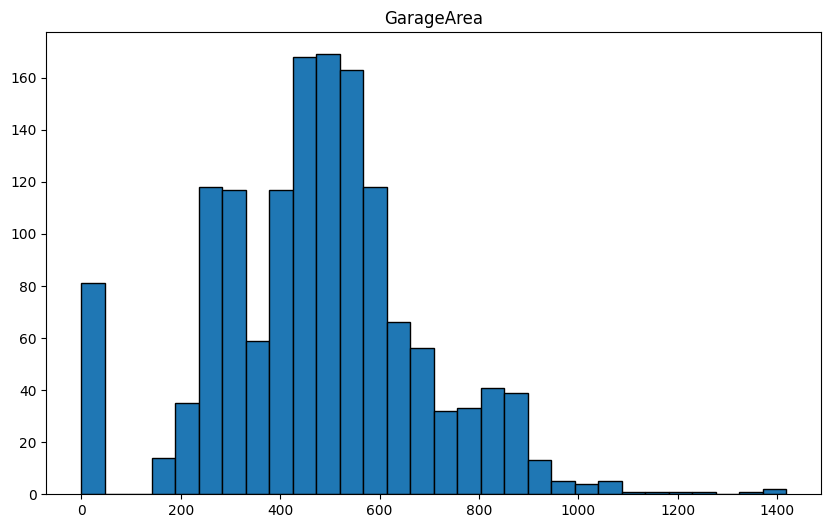

<Figure size 1000x600 with 0 Axes>

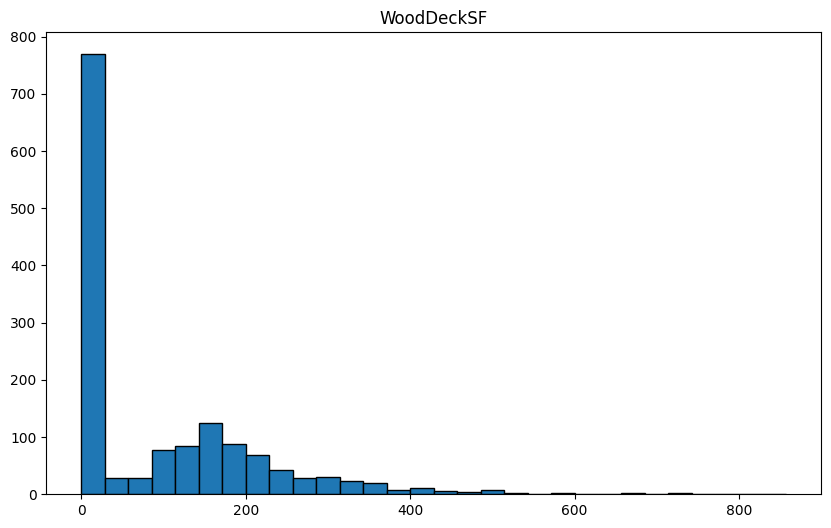

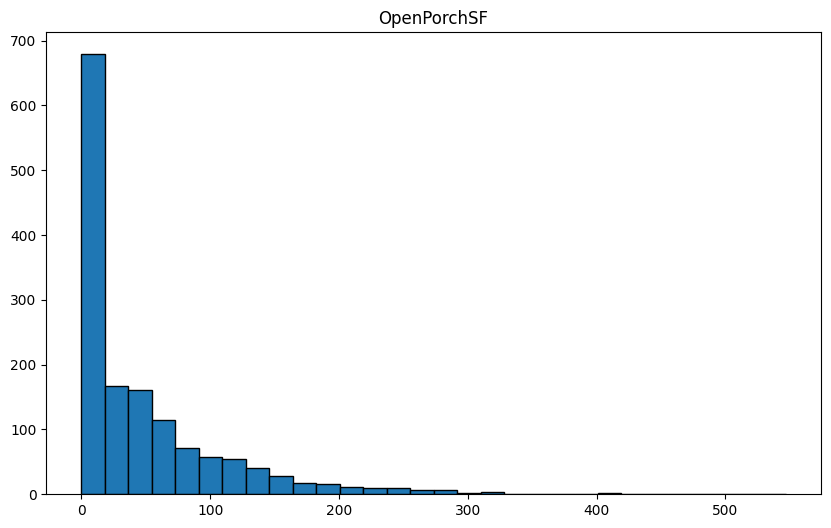

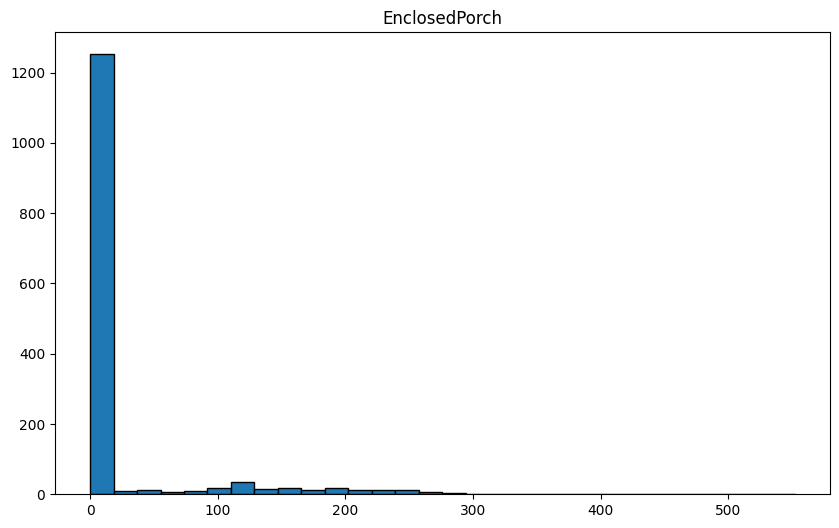

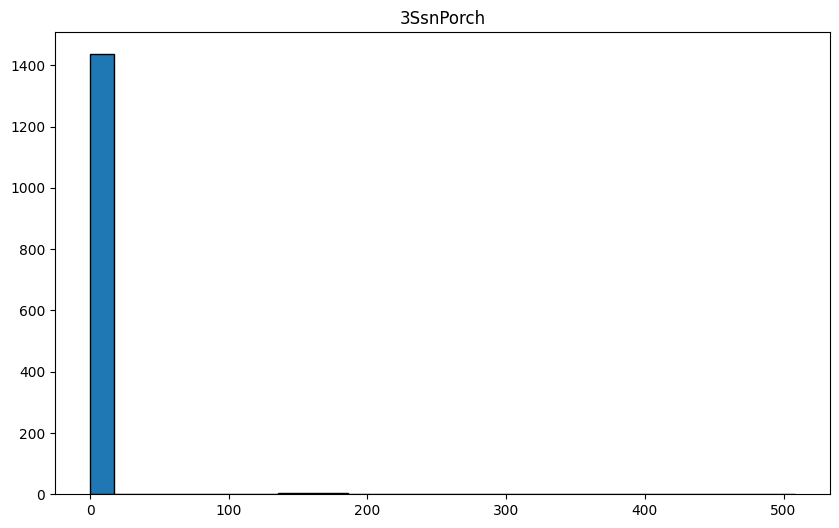

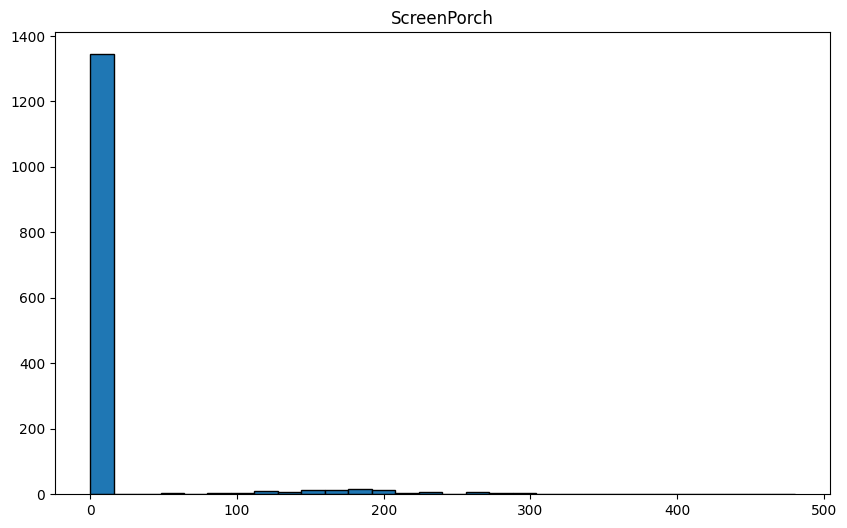

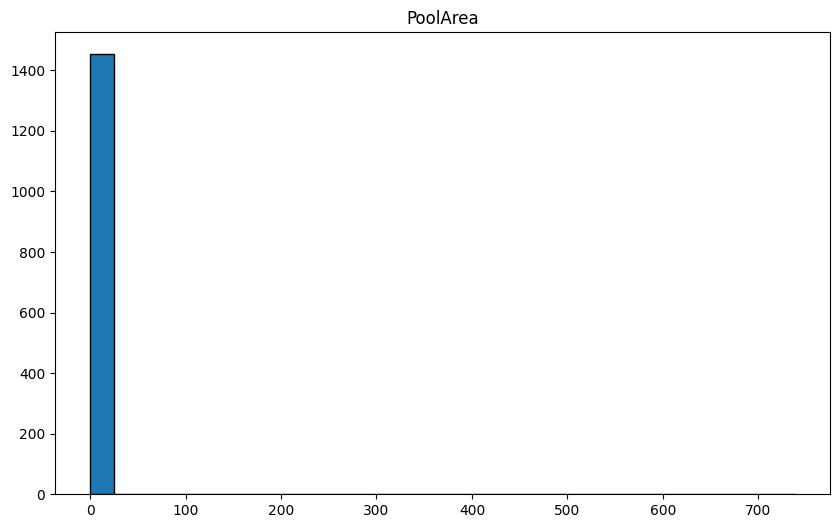

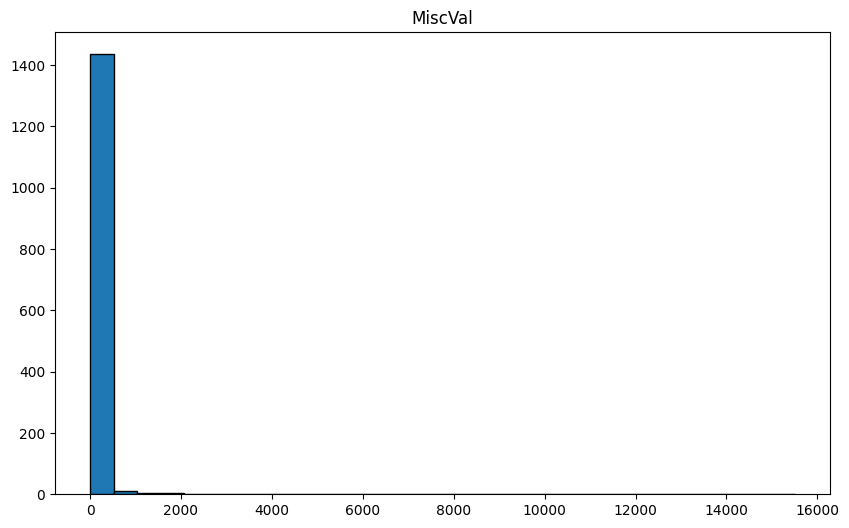

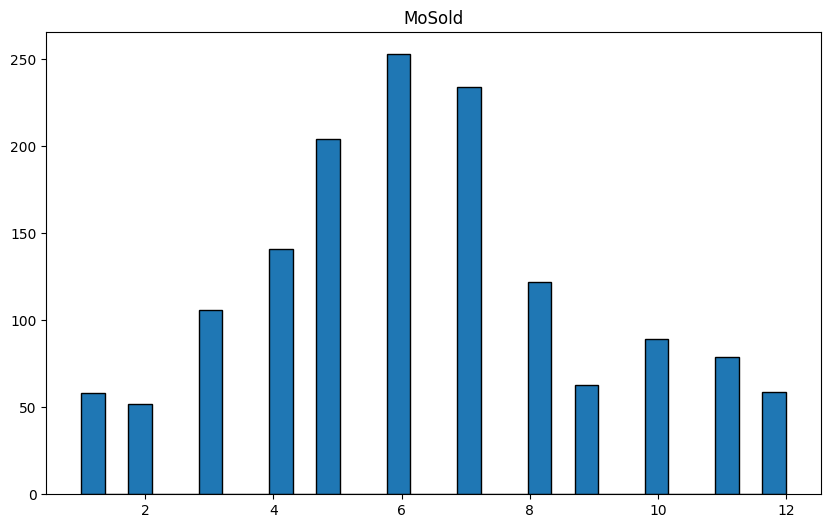

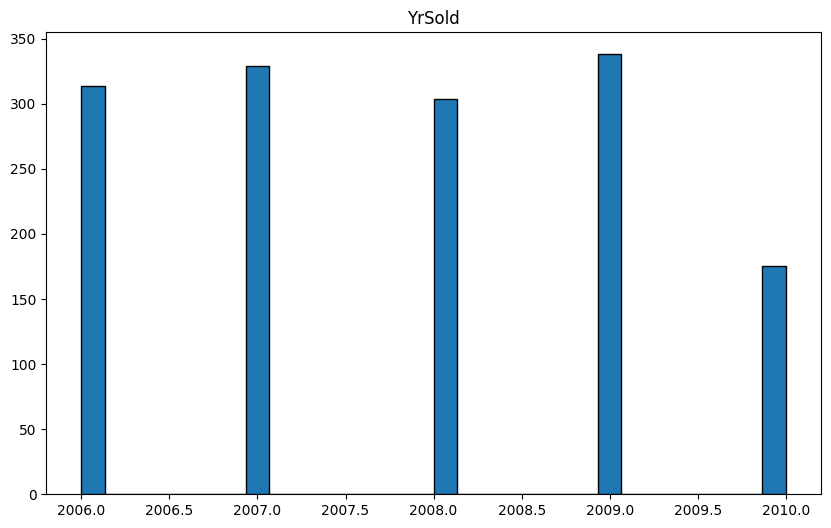

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [49]:
# Plot the numerical explanatory variables. Ma
for col in train.columns:
    if col != 'SalePrice':
        # resize the figure for better visibility by making it smaller
        plt.figure(figsize=(10, 6))
        if train[col].dtype != 'string':
            plt.hist(train[col].dropna(), bins=30, edgecolor='black')
            plt.title(col)


# convert 1/2 to 0/1